In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sys.path.append(str(Path().resolve().parents[0]))

from scripts.data.modeling import entrenar_modelo
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    ConfusionMatrixDisplay
)


In [2]:
ruta_proyecto = Path().resolve().parents[0]

sys.path.append(str(ruta_proyecto))

ruta_csv = ruta_proyecto / "data" / "processed"

X_modelado = pd.read_csv(ruta_csv / "X_modelado.csv")

y_modelado = pd.read_csv(ruta_csv / "y_modelado.csv")

In [3]:
model, X_test, y_test = entrenar_modelo(
    X_modelado,
    y_modelado
)

C:\Users\ERIKA PINCHAO\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [4]:
# Predicción final de clases
y_pred = model.predict(X_test)

# Probabilidades de supervivencia
y_prob = model.predict_proba(X_test)[:, 1]

In [5]:
print("F1 Score:")
print( f1_score(y_test, y_pred))

F1 Score:
0.7755102040816327


In [6]:
print("AUC Score:")
print( roc_auc_score(y_test, y_prob))

AUC Score:
0.8881595881595881


In [7]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [8]:
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[89 16]
 [17 57]]


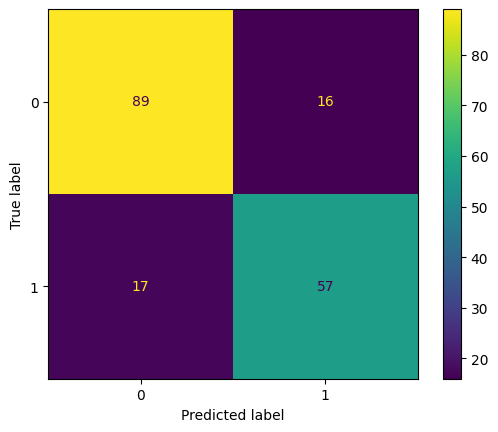

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [10]:
coeficientes = pd.DataFrame({

    "feature": X_modelado.columns,

    "coeficiente": model.coef_[0]
})

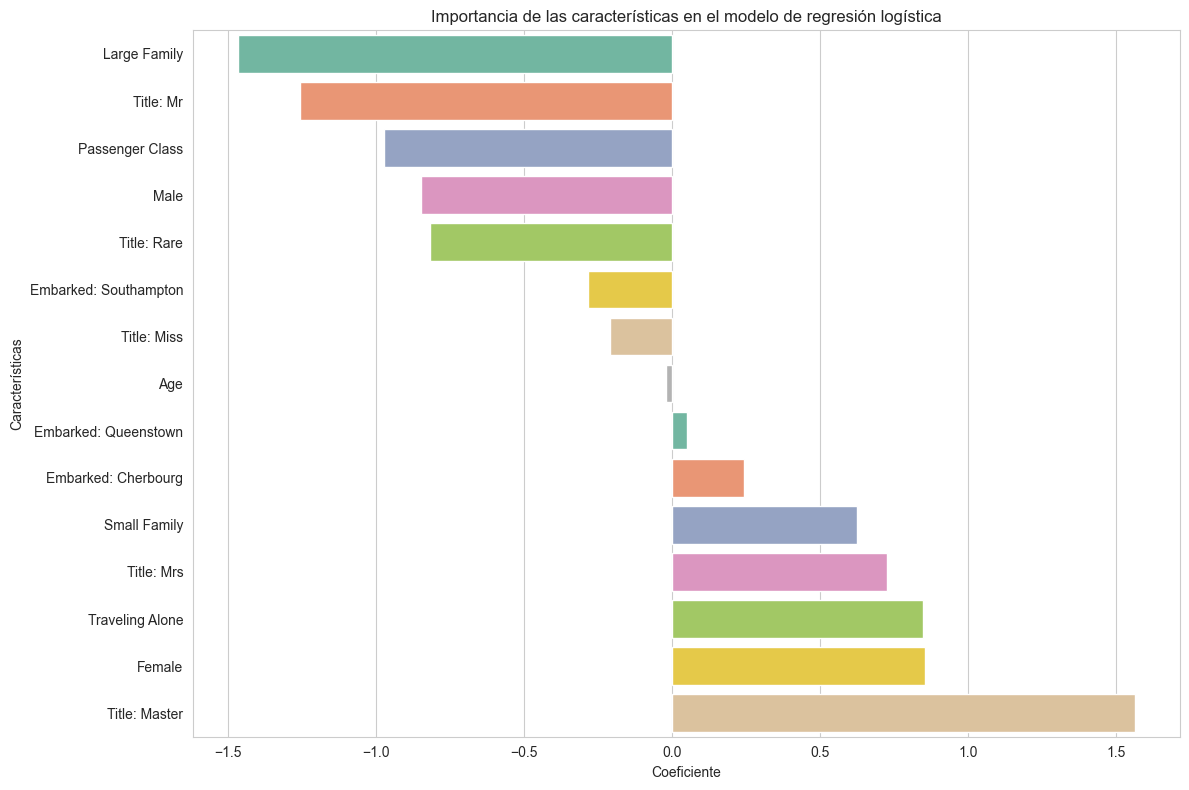

In [11]:
coeficientes_ordenados = coeficientes.sort_values(
    by="coeficiente"
)

# Renombrar variables
coeficientes_ordenados["feature"] = (
    coeficientes_ordenados["feature"]
    .replace({

        "cat__Title_Master": "Title: Master",
        "cat__Title_Mrs": "Title: Mrs",
        "cat__Title_Miss": "Title: Miss",
        "cat__Title_Mr": "Title: Mr",
        "cat__Title_Rare": "Title: Rare",

        "cat__Sex_female": "Female",
        "cat__Sex_male": "Male",

        "ordinal__Pclass": "Passenger Class",

        "num__Age": "Age",

        "cat__Family_group_grande": "Large Family",
        "cat__Family_group_pequena": "Small Family",
        "cat__Family_group_solo": "Traveling Alone",

        "cat__Embarked_C": "Embarked: Cherbourg",
        "cat__Embarked_Q": "Embarked: Queenstown",
        "cat__Embarked_S": "Embarked: Southampton"
    })
)

# Configurar estilo
sns.set_style("whitegrid")

# Crear figura
plt.figure(figsize=(12,8))

# Crear gráfico
sns.barplot(
    data=coeficientes_ordenados,
    x="coeficiente",
    y="feature",
    palette="Set2"
)

plt.title("Importancia de las características en el modelo de regresión logística")
plt.xlabel("Coeficiente")
plt.ylabel("Características")   
plt.tight_layout()
plt.show()
